## Read a grayscale image and perform the following operations. Compare different edge detection algorithms implemented in spatial domain.  


In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

## Loading Original Image

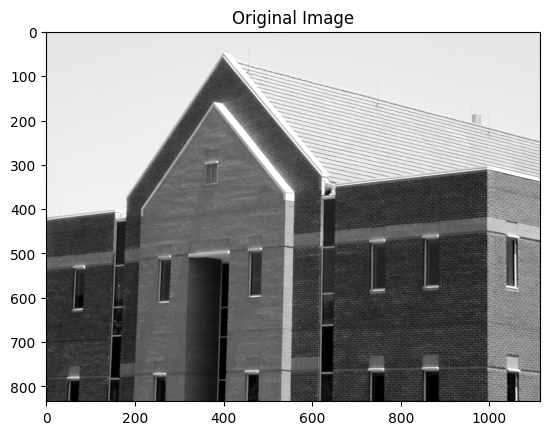

In [3]:
original_image = cv2.imread("./building.tif", 0)
plt.imshow(original_image, cmap='gray')
plt.title("Original Image")
plt.show()

## Edge Detection Function

In [4]:
def detect_edge(image, kernel_x, kernel_y):
    h, w = kernel_x.shape
    padded = np.pad(image, ((1, 1), (1, 1)), mode='constant', constant_values=0)
    gradient_x = np.zeros_like(image)
    gradient_y = np.zeros_like(image)

    for r in range(image.shape[0]):
        for c in range(image.shape[1]):
            region = padded[r:r+h, c:c+w]
            gx = np.sum(region * kernel_x)
            gy = np.sum(region * kernel_y)

            gradient_x[r,c] = gx
            gradient_y[r,c] = gy

    # Compute gradient magnitude
    magnitude = np.sqrt(gradient_x ** 2 + gradient_y ** 2)
    magnitude = (magnitude - np.min(magnitude)) / (np.max(magnitude) - np.min(magnitude)) * 255

    return np.uint8(magnitude)

## sobel Edge detector 

In [6]:
def sobel_edge_detection(image):
    # Convert to float for accurate computation
    # image = img.copy(img)
    image = image.astype(np.float32)

    # Define Sobel kernels
    sobel_x = np.array([
        [-1, 0, 1],
        [-2, 0, 2],
        [-1, 0, 1]
    ], dtype=np.float32)

    sobel_y = np.array([
        [-1, -2, -1],
        [ 0,  0,  0],
        [ 1,  2,  1]
    ], dtype=np.float32)
    
    return detect_edge(image, sobel_x, sobel_y)


## prewitt edge detector

In [7]:
def prewitt_edge_detection(image):
    # Convert to float for accurate computation
    image = image.astype(np.float32)

    # Define prewitt kernels
    prewitt_x = np.array([
        [-1, 0, 1],
        [-1, 0, 1],
        [-1, 0, 1]
    ], dtype=np.float32)

    prewitt_y = np.array([
        [-1, -1, -1],
        [ 0,  0,  0],
        [ 1,  1,  1]
    ], dtype=np.float32)
    
    return detect_edge(image, prewitt_x, prewitt_y)

## Roberts Edge detection

In [8]:
def roberts_edge_detection(image):
    # Convert to float for accurate computation
    image = image.astype(np.float32)

    # Define robert kernels
    robert_x = np.array([
        [-1, 0],
        [0, 1]
    ], dtype=np.float32)

    robert_y = np.array([
        [0, -1],
        [1,  0]
    ], dtype=np.float32)
    
    return detect_edge(image, robert_x, robert_y)

## (a) Compare different edge detection algorithms implemented in spatial domain

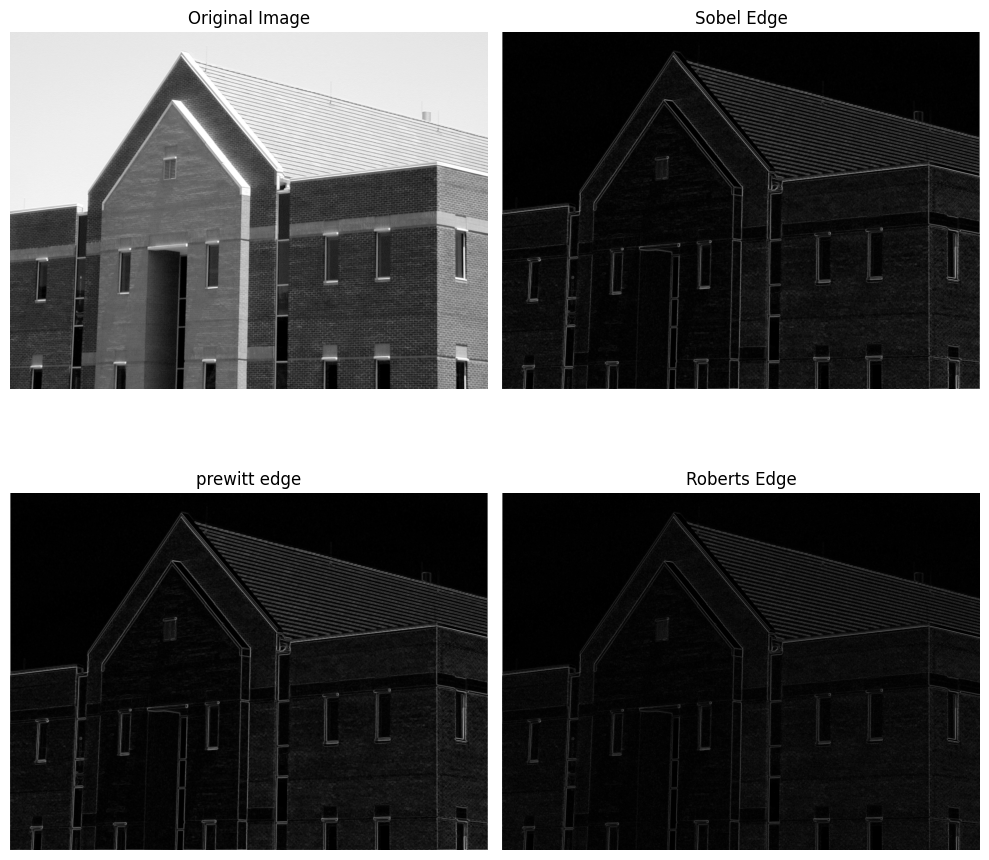

In [16]:
sobel_edge = sobel_edge_detection(original_image)
prewitt_edge = prewitt_edge_detection(original_image)
roberts_edge = roberts_edge_detection(original_image)

plt.figure(figsize=(10, 10))

plt.subplot(2, 2, 1)
plt.imshow(original_image, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(sobel_edge, cmap='gray')
plt.title("Sobel Edge")
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(prewitt_edge, cmap='gray')
plt.title("prewitt edge")
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(roberts_edge, cmap='gray')
plt.title('Roberts Edge')
plt.axis('off')

plt.tight_layout()
plt.show()